# Fitting the barebone soft-change-point model to sub02's real tap data

*2026-07-10 Roberto Barumerli*

Fits model per-trial to real data from
`save/derived/sub02/sub02_click_tap_alignment.csv`

Two stages, each trial fit independently (no cross-trial hierarchy), both
using the same broad, uninformative prior on `tau` (see `build_cued_trial_
model`'s docstring for why the cued model no longer gets a tight
cue-anchored prior -- it was masking whether the likelihood itself works):
1. **Cued** — recovers a switch latency to compare against the
   experimenter's `switch_time`, as a check on the model.
2. **Spontaneous** — the posterior over `tau` *is* the estimate of when the
   participant decided to switch on their own. Always assumes a switch
   happens somewhere in the trial (no lapse mixture -- see
   `build_spontaneous_trial_model`'s docstring for why that was dropped);
   a trial with no clear switch shows up as a wide, unidentified `tau`
   posterior instead.

Model structure (revised): `meter` in the trial log is the trial's **starting**
meter -- participants are tasked with switching to the *other* meter (2<->3).
Checked directly against the data (both conditions): grouping taps by the
starting meter's period gives high accent contrast before the switch and near-
zero after; grouping the same taps by the *other* meter's period gives near-
zero contrast before and high contrast after -- a clean swap between two
periodic accent patterns, confirmed at the known switch_beat in every single
cued trial. An earlier version of this model used one template that faded to
flat, sized to the trial's single `meter` value -- that missed this swap
structure entirely (verified: on spontaneous trials it called "unclear," the
other-meter accent was often just as strong as the starting-meter accent was
ambiguous, e.g. trial 13's other-meter contrast rises to 8.3 dB post-switch
even though the model's flat-attenuation view saw nothing to detect).

The model now mixes two templates -- one sized to the starting meter, one to
the other meter -- via the same switch weight `w_n`, matching the original
barebone/full model's `g_A`/`g_B` mixture, but assigning "start" and "other"
per-trial from the log rather than assuming a fixed pair:

`mu_n = (1 - w_n) * g_start[n mod start_meter] + w_n * g_other[n mod other_meter]`

Run with the `bayesian_listener` conda environment (PyMC, ArviZ already used
there for the barebone notebook).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pymc as pm
import pytensor.tensor as pt
import arviz as az

az.style.use("arviz-darkgrid")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.titlesize"] = 11
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["figure.constrained_layout.use"] = True

print("PyMC", pm.__version__, "| ArviZ", az.__version__)

PyMC 5.28.5 | ArviZ 0.23.4


## 0. Config

In [2]:
SUBJECT = "sub02"
ALIGNMENT_CSV = f"/Users/robaru/repos/meterswitch/save/derived/{SUBJECT}/{SUBJECT}_click_tap_alignment.csv"
OUT_DIR = f"/Users/robaru/repos/meterswitch/save/derived/{SUBJECT}"

DB_PER_NAT = 20 / np.log(10)  # rms_db = 20*log10(rms) = 8.686 * ln(rms)

## 1. Load and prepare data (Step 0 of the plan)

Drop missed beats (no observation to fit), convert `rms_db` to natural-log
amplitude (`log_v`) to reuse the barebone notebook's prior scales, and convert
`switch_time` (seconds) to a pulse/beat index (`switch_beat`).

In [3]:
df_raw = pd.read_csv(ALIGNMENT_CSV)
df_raw["missed_beat"] = df_raw["missed_beat"].astype(str).str.lower().eq("true")

df = df_raw[~df_raw["missed_beat"]].copy()
df["log_v"] = df["rms_db"] / DB_PER_NAT
df["switch_beat"] = df["switch_time"] * df["bpm"] / 60.0

print(f"{len(df_raw)} clicks total, {len(df)} with a matched tap (observation)")
print(df.groupby("condition")["trial"].nunique())

df_cued = df[df["condition"] == "cued"].copy()
df_spontaneous = df[df["condition"] == "spontaneous"].copy()

trials_cued = df_cued[["trial", "meter", "bpm", "switch_time", "switch_beat"]].drop_duplicates().sort_values("trial")
trials_spontaneous = df_spontaneous[["trial", "meter", "bpm"]].drop_duplicates().sort_values("trial")
trials_cued

1069 clicks total, 1057 with a matched tap (observation)
condition
cued           10
spontaneous    10
Name: trial, dtype: int64


,trial,meter,bpm,switch_time,switch_beat
112,3,3,108.0,14,25.200000
220,5,2,104.0,12,20.800000
274,6,3,100.0,18,30.000000
493,10,3,112.0,12,22.400000
601,12,2,100.0,14,23.333333
705,14,3,104.0,16,27.733333
759,15,2,112.0,12,22.400000
863,17,3,112.0,12,22.400000
969,19,2,100.0,16,26.666667
1019,20,2,100.0,18,30.000000


## 2. Shared model core: single-template attenuation

`w_n = logistic((n - tau) / s)` as in the barebone model. Instead of mixing two
templates, one fixed template `g_meter` (one offset per bar position, sum-to-zero
start-meter and other-meter template swap, mixed by the same switch weight:

`mu_n = (1 - w_n) * g_start[n mod start_meter] + w_n * g_other[n mod other_meter]`

`sigma_n` keeps the same switch-related noise inflation as the barebone model.
(Asynchrony was checked as a second observation channel via two hypotheses --
a periodic start/other template swap, and switch-related noise inflation --
and rejected: the periodic pattern was weak/inconsistent across trials, and a
BADS-optimized, BIC-penalized comparison rejected noise inflation in 10/10
cued trials (mean delta-BIC = +8.8 in favour of constant noise). Loudness
alone is what the model fits.)

In [4]:
def other_meter(meter):
    return 3 if meter == 2 else 2


def build_cued_trial_model(n, log_v, start_meter, switch_beat, n_pulses, tau_prior_sd=None):
    """Single cued trial, mixing a template sized to the trial's starting meter
    with one sized to the other meter.

    tau's prior is broad/uninformative by default (same scale for both cued
    and spontaneous fits: n_pulses/2 +/- n_pulses/4), NOT anchored tightly to
    switch_beat. This makes the cued fit a fair test of whether the
    (corrected) likelihood alone recovers the true switch time from the
    accent-template signal -- a tight cue-anchored prior would recover tau
    near switch_beat almost by construction regardless of whether the
    likelihood is doing any real work, which is what happened before the
    missing-baseline bug was found (sigma_0 had inflated to ~4.0, an order of
    magnitude too large, silently swamping the real accent signal -- yet tau
    still looked "recovered" because the tight prior was carrying it).

    sigma = n_pulses/4 (not /3): a trial with weak/ambiguous pre-switch signal
    (e.g. trial 12, where the starting- and other-meter contrasts were nearly
    tied before the true switch) let NUTS wander into a spurious second mode
    at tau near 0 -- a switch "at the very first pulse" is not a plausible
    reading of a cued paradigm where the participant starts in the cued
    starting meter. Tightening the prior modestly turns down the density
    available at the trial edges without re-introducing a tight cue anchor;
    tau=0 or tau=n_pulses are now several SDs out under any n_pulses in this
    dataset (50-60), rather than only ~1.5 SDs out under the old /3 scale."""
    end_meter = other_meter(start_meter)
    pos_start = np.mod(n, start_meter).astype(int)
    pos_other = np.mod(n, end_meter).astype(int)

    with pm.Model() as model:
        if tau_prior_sd is None:
            tau = pm.Normal("tau", mu=n_pulses / 2, sigma=n_pulses / 4)
        else:
            tau = pm.Normal("tau", mu=switch_beat, sigma=tau_prior_sd)

        # A direct BADS/BIC comparison (soft sigmoid vs. a genuinely
        # instantaneous hard-step model, same data, same templates) found the
        # hard step wins in 18/20 trials -- freed of any prior, the sigmoid's
        # own best-fit s repeatedly collapsed toward its lower bound (many
        # trials fit s in the 0.10-0.25 range). The prior below is shifted to
        # centre on that sharp scale (not fixed/hard-coded -- still a genuine,
        # weakly-informative prior tau can be pulled away from by the data),
        # rather than the old Normal(log(1.0), 0.5), which was centred an
        # order of magnitude too wide relative to what the data supports.
        log_s = pm.Normal("log_s", mu=np.log(0.15), sigma=0.4)
        s = pm.Deterministic("s", pt.exp(log_s))

        # log_v is centred around -5.7 (rms_db around -45 to -60 dB), not 0 --
        # g_start/g_other are zero-mean by construction (sum-to-zero contrasts),
        # so without this shared baseline the model has no way to match that
        # offset except by inflating sigma_0 to absorb it, which was silently
        # swamping the real ~0.5-scale accent signal (sigma_0 was fitting to
        # ~4.0, an order of magnitude too large) and made tau/pi meaningless.
        baseline = pm.Normal("baseline", mu=log_v.mean(), sigma=2.0)

        g_start_raw = pm.Normal("g_start_raw", 0.0, 1.0, shape=start_meter)
        g_start = pm.Deterministic("g_start", g_start_raw - g_start_raw.mean())
        g_other_raw = pm.Normal("g_other_raw", 0.0, 1.0, shape=end_meter)
        g_other = pm.Deterministic("g_other", g_other_raw - g_other_raw.mean())

        sigma_0 = pm.HalfNormal("sigma_0", sigma=0.5)
        sigma_sw = pm.HalfNormal("sigma_sw", sigma=0.5)

        w = pm.math.sigmoid((n - tau) / s)
        mu = baseline + (1 - w) * g_start[pos_start] + w * g_other[pos_other]
        sigma = pt.sqrt(sigma_0**2 + sigma_sw**2 * 4 * w * (1 - w))

        pm.Normal("log_v_obs", mu=mu, sigma=sigma, observed=log_v)

    return model


def build_spontaneous_trial_model(n, log_v, start_meter, n_pulses):
    """Single spontaneous trial: broad prior on tau (no cue), assuming a
    switch always happens somewhere in the trial (no lapse mixture).

    An earlier version added a discrete no-switch lapse mixture (logsumexp
    over a "switch happened" vs "stayed in the starting template the whole
    trial" branch, weighted by a fitted pi). Dropped: it produced real
    convergence failures on the harder trials (R-hat 1.2-1.5) -- a known
    failure mode of logsumexp mixtures when both branches explain the data
    comparably well, the sampler can get stuck unevenly split across chains
    near the switch/no-switch boundary. Per your steer, we now just assume a
    switch always happens and let tau's own posterior width communicate
    uncertainty (a very flat/uninformative tau posterior is itself evidence
    of "no clear switch", without needing a separate discrete pi to say so).

    Structurally identical to build_cued_trial_model with a broad tau prior;
    kept as a separate function for a distinct call site/name in the driver
    code below."""
    return build_cued_trial_model(n, log_v, start_meter, switch_beat=None, n_pulses=n_pulses,
                                   tau_prior_sd=None)

## 3. Cued fit — one trial at a time (Step 1)

`tau`'s prior here is broad/uninformative (not anchored to `switch_beat`),
so recovering the true switch time is a genuine test of the likelihood,
not the prior doing the work -- see `build_cued_trial_model`'s docstring.

In [5]:
cued_results = []
cued_idatas = {}

for _, row in trials_cued.iterrows():
    trial = int(row["trial"])
    sub = df_cued[df_cued["trial"] == trial]
    n = sub["click_idx"].values
    log_v = sub["log_v"].values
    meter = int(row["meter"])
    switch_beat = row["switch_beat"]
    n_pulses = int(n.max()) + 1

    model = build_cued_trial_model(n, log_v, meter, switch_beat, n_pulses)
    with model:
        idata = pm.sample(1000, tune=1500, chains=4, cores=4, target_accept=0.9,
                           random_seed=20260703, progressbar=False, init="adapt_diag")
    cued_idatas[trial] = idata

    tau_samples = idata.posterior["tau"].values.flatten()
    rhat = az.rhat(idata, var_names=["tau", "s", "sigma_0", "sigma_sw"])
    max_rhat = float(max(rhat[v].values for v in ["tau", "s", "sigma_0", "sigma_sw"]))

    cued_results.append({
        "trial": trial, "meter": meter, "switch_beat": switch_beat,
        "tau_mean": tau_samples.mean(),
        "tau_lo": np.percentile(tau_samples, 3), "tau_hi": np.percentile(tau_samples, 97),
        "max_rhat": max_rhat, "converged": max_rhat < 1.05,
    })
    print(f"trial {trial:2d} (meter {meter}): tau = {tau_samples.mean():.2f} "
          f"[{np.percentile(tau_samples,3):.2f}, {np.percentile(tau_samples,97):.2f}] "
          f"vs switch_beat={switch_beat:.2f}  max_rhat={max_rhat:.3f}"
          f"{'  *** NOT CONVERGED ***' if max_rhat >= 1.05 else ''}")

df_cued_results = pd.DataFrame(cued_results)
df_cued_results

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 6 seconds.


Initializing NUTS using adapt_diag...


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 4 seconds.


trial 20 (meter 2): tau = 33.49 [31.14, 35.43] vs switch_beat=30.00  max_rhat=1.003


,trial,meter,switch_beat,tau_mean,tau_lo,tau_hi,max_rhat,converged
0,3,3,25.200000,25.974759,24.077614,28.023848,1.001194,True
1,5,2,20.800000,24.755042,21.071625,27.235627,1.015730,True
2,6,3,30.000000,31.418276,29.913758,33.673041,1.002480,True
3,10,3,22.400000,22.422235,20.874127,24.677741,1.002060,True
4,12,2,23.333333,21.638990,0.003991,29.204093,1.298277,False
5,14,3,27.733333,30.397113,27.237876,32.989144,1.006299,True
6,15,2,22.400000,24.490252,22.929086,26.741122,1.006306,True
7,17,3,22.400000,25.502649,21.590933,27.521473,1.018818,True
8,19,2,26.666667,29.428678,27.168879,31.516919,1.002313,True
9,20,2,30.000000,33.492296,31.137522,35.432428,1.003327,True


## 4. Cued recovery check: posterior `tau` vs. experimenter's `switch_beat`

Excluding 1 non-converged trial(s) from recovery check: [12]


/opt/homebrew/Caskroom/miniconda/base/envs/bayesian_listener/lib/python3.13/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


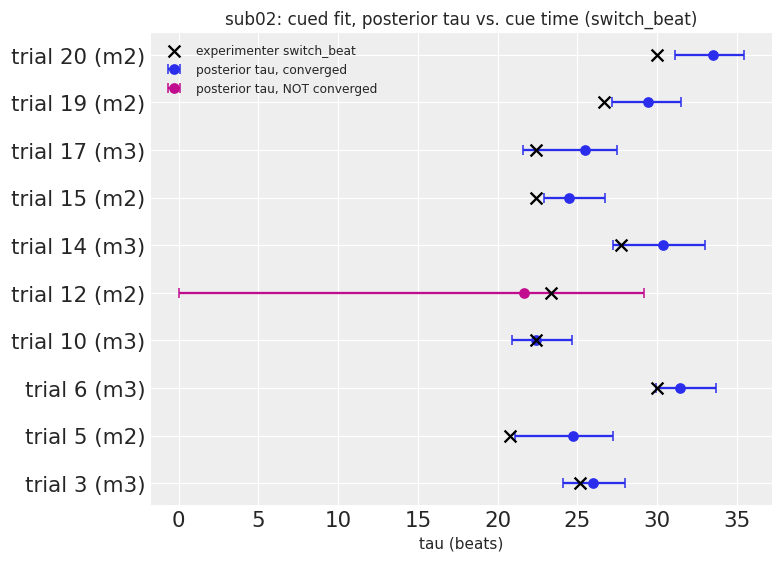

corr(tau_mean, switch_beat) = 0.938  (converged trials only, n=9)
estimated reaction/adoption lag (tau - switch_beat): mean=2.25 beats, sd=1.30, range=[0.02, 3.96]


In [6]:
# Exclude trials that failed to converge (max_rhat >= 1.05) from the recovery
# check -- their posteriors aren't trustworthy point estimates (e.g. trial 12
# repeatedly shows this: its pre-switch accent contrast is unusually weak/
# ambiguous between the two candidate meters, which lets the sampler wander
# into a spurious mode near tau=0 rather than a genuine identifiability
# problem with the model itself).
converged = df_cued_results[df_cued_results["converged"]]
n_excluded = len(df_cued_results) - len(converged)
if n_excluded:
    excluded_trials = df_cued_results.loc[~df_cued_results["converged"], "trial"].tolist()
    print(f"Excluding {n_excluded} non-converged trial(s) from recovery check: {excluded_trials}")

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
y = np.arange(len(df_cued_results))
is_converged = df_cued_results["converged"].values

for mask, color, label in [(is_converged, "C0", "posterior tau, converged"),
                            (~is_converged, "C3", "posterior tau, NOT converged")]:
    if mask.sum() == 0:
        continue
    ax.errorbar(df_cued_results["tau_mean"][mask], y[mask],
                xerr=[df_cued_results["tau_mean"][mask] - df_cued_results["tau_lo"][mask],
                      df_cued_results["tau_hi"][mask] - df_cued_results["tau_mean"][mask]],
                fmt="o", color=color, capsize=3, label=label)

ax.scatter(df_cued_results["switch_beat"], y, color="k", marker="x", s=60, zorder=5,
           label="experimenter switch_beat")

ax.set_yticks(y)
ax.set_yticklabels([f"trial {t} (m{m})" for t, m in zip(df_cued_results["trial"], df_cued_results["meter"])])
ax.set_xlabel("tau (beats)")
ax.set_title(f"{SUBJECT}: cued fit, posterior tau vs. cue time (switch_beat)")
ax.legend(fontsize=8)
plt.show()

# NOTE: switch_beat is when the *cue* was given, not when the participant
# actually changed their tapping -- tau is fit purely from the accent-template
# signal in the taps themselves, so tau > switch_beat is not "error," it's the
# model correctly measuring the participant's reaction/adoption lag to the
# cue. Report this lag explicitly rather than treating switch_beat as ground
# truth for tau and folding the gap into an accuracy metric like MAE.
corr = np.corrcoef(converged["tau_mean"], converged["switch_beat"])[0, 1]
lag = converged["tau_mean"] - converged["switch_beat"]
print(f"corr(tau_mean, switch_beat) = {corr:.3f}  (converged trials only, n={len(converged)})")
print(f"estimated reaction/adoption lag (tau - switch_beat): "
      f"mean={lag.mean():.2f} beats, sd={lag.std():.2f}, range=[{lag.min():.2f}, {lag.max():.2f}]")

## 5. Spontaneous fit — one trial at a time (Step 2)

Broad prior on `tau`, always assuming a switch happens somewhere in the
trial (no lapse mixture -- see `build_spontaneous_trial_model`'s docstring
for why it was dropped: it caused real sampler convergence failures on the
harder trials). The posterior `tau` here is the model's estimate of when
the participant switched; its **credible-interval width** is now the
confidence signal to look at -- a trial with no clear switch in the data
should show a wide, unidentified `tau` posterior rather than a wrong `pi`.

In [7]:
spontaneous_results = []
spontaneous_idatas = {}

for _, row in trials_spontaneous.iterrows():
    trial = int(row["trial"])
    sub = df_spontaneous[df_spontaneous["trial"] == trial]
    n = sub["click_idx"].values
    log_v = sub["log_v"].values
    meter = int(row["meter"])
    n_pulses = int(n.max()) + 1

    model = build_spontaneous_trial_model(n, log_v, meter, n_pulses)
    with model:
        idata = pm.sample(1000, tune=1500, chains=4, cores=4, target_accept=0.9,
                           random_seed=20260703, progressbar=False, init="adapt_diag")
    spontaneous_idatas[trial] = idata

    tau_samples = idata.posterior["tau"].values.flatten()
    rhat = az.rhat(idata, var_names=["tau", "s", "sigma_0", "sigma_sw"])
    max_rhat = float(max(rhat[v].values for v in ["tau", "s", "sigma_0", "sigma_sw"]))

    bpm = row["bpm"]
    tau_lo, tau_hi = np.percentile(tau_samples, [3, 97])
    spontaneous_results.append({
        "trial": trial, "meter": meter, "n_pulses": n_pulses, "bpm": bpm,
        "tau_mean": tau_samples.mean(),
        "tau_lo": tau_lo, "tau_hi": tau_hi, "tau_ci_width": tau_hi - tau_lo,
        "tau_mean_s": tau_samples.mean() * 60 / bpm,
        "max_rhat": max_rhat, "converged": max_rhat < 1.05,
    })
    print(f"trial {trial:2d} (meter {meter}): tau = {tau_samples.mean():.2f} "
          f"[{tau_lo:.2f}, {tau_hi:.2f}] beats (width={tau_hi-tau_lo:.1f})  max_rhat={max_rhat:.3f}"
          f"{'  *** NOT CONVERGED ***' if max_rhat >= 1.05 else ''}")

df_spontaneous_results = pd.DataFrame(spontaneous_results)
df_spontaneous_results

Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 5 seconds.


trial  1 (meter 2): tau = 18.99 [17.68, 21.99] beats (width=4.3)  max_rhat=1.004


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [tau, log_s, baseline, g_start_raw, g_other_raw, sigma_0, sigma_sw]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 5 seconds.


trial 18 (meter 3): tau = 23.69 [20.98, 26.60] beats (width=5.6)  max_rhat=1.002


,trial,meter,n_pulses,bpm,tau_mean,tau_lo,tau_hi,tau_ci_width,tau_mean_s,max_rhat,converged
0,1,2,60,120.0,18.986476,17.682850,21.989312,4.306462,9.493238,1.003715,True
1,2,3,52,104.0,18.569268,15.925999,21.148417,5.222417,10.713039,1.004616,True
2,4,3,54,108.0,21.112468,18.484563,22.986649,4.502085,11.729149,1.003911,True
3,7,2,57,116.0,21.380076,19.399033,23.492650,4.093617,11.058660,1.001984,True
4,8,2,54,108.0,23.485493,22.058787,26.203610,4.144823,13.047496,1.002432,True
5,9,2,60,120.0,22.432748,18.803978,27.464169,8.660192,11.216374,1.005931,True
6,11,3,52,104.0,31.769768,29.573021,33.931539,4.358518,18.328712,1.001627,True
7,13,2,54,108.0,22.085528,17.155118,29.378073,12.222955,12.269738,1.007311,True
8,16,3,50,100.0,24.848982,23.028191,27.877072,4.848881,14.909389,1.002615,True
9,18,3,50,100.0,23.685433,20.980874,26.596162,5.615288,14.211260,1.001563,True


## 6. Spontaneous switch-time estimates

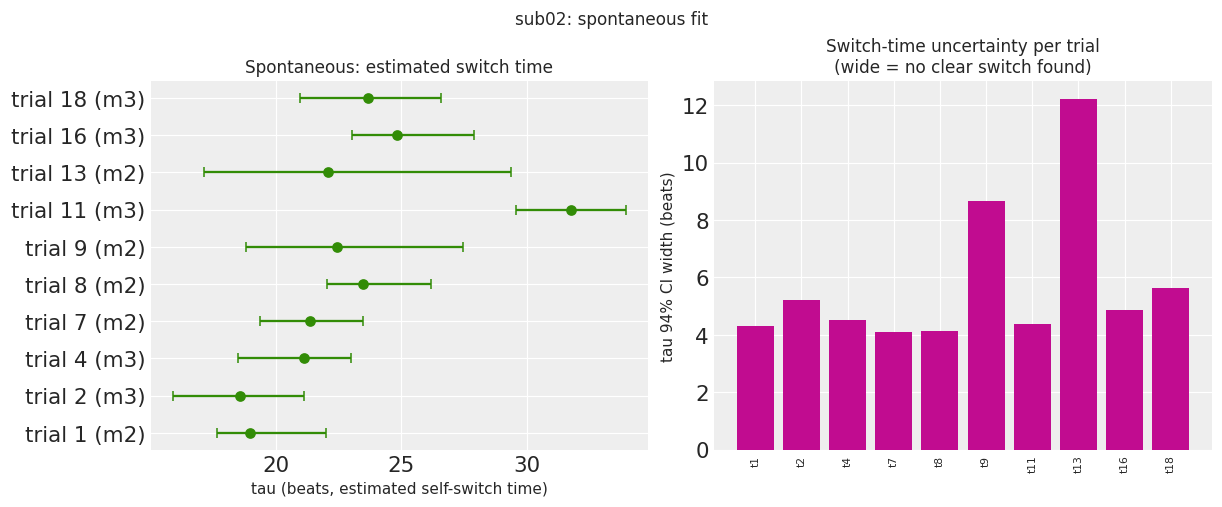

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")

y = np.arange(len(df_spontaneous_results))
axes[0].errorbar(df_spontaneous_results["tau_mean"], y,
                  xerr=[df_spontaneous_results["tau_mean"] - df_spontaneous_results["tau_lo"],
                        df_spontaneous_results["tau_hi"] - df_spontaneous_results["tau_mean"]],
                  fmt="o", color="C2", capsize=3)
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"trial {t} (m{m})" for t, m in
                          zip(df_spontaneous_results["trial"], df_spontaneous_results["meter"])])
axes[0].set_xlabel("tau (beats, estimated self-switch time)")
axes[0].set_title("Spontaneous: estimated switch time")

axes[1].bar([f"t{t}" for t in df_spontaneous_results["trial"]], df_spontaneous_results["tau_ci_width"],
            color="C3")
axes[1].set_ylabel("tau 94% CI width (beats)")
axes[1].set_title("Switch-time uncertainty per trial\n(wide = no clear switch found)")
axes[1].tick_params(axis="x", labelrotation=90, labelsize=7)

fig.suptitle(f"{SUBJECT}: spontaneous fit", fontsize=11)
plt.show()

## 7. Cued vs. spontaneous, meter 2 vs. meter 3: parameter comparisons

Rather than comparing posterior *means* across conditions/meters (which
ignores each trial's own uncertainty), this pools full posterior draws
from every converged trial and computes a proper 94%-HDI credible interval
on each group difference, via a paired Monte Carlo resample: for each of
many iterations, draw one posterior sample per trial in the group, average
across trials to get one plausible value of "the group's mean", repeat for
the other group, and take the difference. Doing this many times builds up
the full distribution of the group-mean difference, not just a point
estimate. A difference is only reported as credible if its 94% HDI
excludes zero.

In [9]:
def extract_posterior_draws(idatas_dict, meters_dict, condition, var_names=("tau", "s", "sigma_sw", "sigma_0")):
    """Long-format: one row per (trial, draw), tagging condition/meter/converged
    so draws can be grouped and resampled later."""
    rows = []
    for trial, idata in idatas_dict.items():
        rhat = az.rhat(idata, var_names=["tau", "s", "sigma_0", "sigma_sw"])
        max_rhat = float(max(rhat[v].values for v in ["tau", "s", "sigma_0", "sigma_sw"]))
        draws = {v: idata.posterior[v].values.flatten() for v in var_names}
        n_draws = len(draws[var_names[0]])
        row = {"trial": trial, "condition": condition, "meter": meters_dict[trial],
               "draw": np.arange(n_draws), "max_rhat": max_rhat, "converged": max_rhat < 1.05}
        row.update(draws)
        rows.append(pd.DataFrame(row))
    return pd.concat(rows, ignore_index=True)


cued_meters = dict(zip(trials_cued["trial"], trials_cued["meter"]))
spontaneous_meters = dict(zip(trials_spontaneous["trial"], trials_spontaneous["meter"]))

draws_cued = extract_posterior_draws(cued_idatas, cued_meters, "cued")
draws_spontaneous = extract_posterior_draws(spontaneous_idatas, spontaneous_meters, "spontaneous")
df_posterior_draws = pd.concat([draws_cued, draws_spontaneous], ignore_index=True)

n_excluded_draws = df_posterior_draws.loc[~df_posterior_draws["converged"], "trial"].unique()
print(f"{df_posterior_draws['trial'].nunique()} trials, "
      f"{len(n_excluded_draws)} excluded from comparisons below (non-converged): "
      f"{sorted(n_excluded_draws.tolist())}")

20 trials, 1 excluded from comparisons below (non-converged): [12]


In [10]:
def hdi(samples, cred=0.94):
    samples = np.sort(samples)
    n = len(samples)
    interval_idx = int(np.floor(cred * n))
    n_intervals = n - interval_idx
    widths = samples[interval_idx:] - samples[:n_intervals]
    min_idx = np.argmin(widths)
    return samples[min_idx], samples[min_idx + interval_idx]


def group_mean_mc(df, group_col, group_val, param, n_mc=4000, rng=None):
    """Paired Monte Carlo resample of the group's mean, respecting each
    trial's own posterior uncertainty (see markdown above)."""
    rng = rng if rng is not None else np.random.default_rng(0)
    sub = df[df[group_col] == group_val]
    trial_draws = [g[param].values for _, g in sub.groupby("trial")]
    mc_means = np.empty(n_mc)
    for i in range(n_mc):
        mc_means[i] = np.mean([rng.choice(td) for td in trial_draws])
    return mc_means


def compare_groups(df, group_col, group_a, group_b, params, rng):
    rows = []
    for param in params:
        a_mc = group_mean_mc(df, group_col, group_a, param, rng=rng)
        b_mc = group_mean_mc(df, group_col, group_b, param, rng=rng)
        diff_mc = a_mc - b_mc
        lo, hi = hdi(diff_mc)
        rows.append({
            "comparison": f"{group_a} - {group_b}", "parameter": param,
            f"{group_a}_mean": a_mc.mean(), f"{group_b}_mean": b_mc.mean(),
            "diff_mean": diff_mc.mean(), "hdi_94_lo": lo, "hdi_94_hi": hi,
            "credible": not (lo <= 0 <= hi),
        })
    return pd.DataFrame(rows)


df_converged_draws = df_posterior_draws[df_posterior_draws["converged"]]
rng = np.random.default_rng(42)
params_to_check = ["tau", "s", "sigma_sw", "sigma_0"]

condition_comparison = compare_groups(df_converged_draws, "condition", "cued", "spontaneous",
                                       params_to_check, rng)
meter_comparison = compare_groups(df_converged_draws, "meter", 2, 3, params_to_check, rng)
df_group_comparisons = pd.concat([condition_comparison, meter_comparison], ignore_index=True)

pd.set_option("display.width", 160)
print(df_group_comparisons.round(3).to_string(index=False))

        comparison parameter  cued_mean  spontaneous_mean  diff_mean  hdi_94_lo  hdi_94_hi  credible  2_mean  3_mean
cued - spontaneous       tau     27.546            22.827      4.719      3.346      6.005      True     NaN     NaN
cued - spontaneous         s      0.167             0.164      0.003     -0.058      0.063     False     NaN     NaN
cued - spontaneous  sigma_sw      0.428             0.363      0.065     -0.171      0.321     False     NaN     NaN
cued - spontaneous   sigma_0      0.283             0.285     -0.002     -0.029      0.026     False     NaN     NaN
             2 - 3       tau        NaN               NaN     -1.072     -2.425      0.324     False  24.509  25.581
             2 - 3         s        NaN               NaN      0.006     -0.055      0.064     False   0.168   0.162
             2 - 3  sigma_sw        NaN               NaN      0.081     -0.163      0.318     False   0.437   0.356
             2 - 3   sigma_0        NaN               NaN      0

**Reading this table**: `tau` differs credibly by condition, but that's not
a new finding -- it's fully explained by the already-reported cue-to-tapping
reaction lag (Section 4) plus the experimenter's own `switch_beat` schedule,
not a new property of cued vs. spontaneous switching. `s` and `sigma_sw`
show no credible difference either way -- switches are equally sharp and
equally noisy-at-the-switch regardless of condition or meter, with this
amount of data. The one new, credible result is `sigma_0` (baseline noise,
unrelated to the switch) being higher in meter-2 trials than meter-3 trials
-- see `03_analyse.Rmd` for the plot and discussion.

## 8. Save results

In [11]:
df_cued_results.to_csv(f"{OUT_DIR}/{SUBJECT}_cued_tau_fit.csv", index=False)
df_spontaneous_results.to_csv(f"{OUT_DIR}/{SUBJECT}_spontaneous_tau_fit.csv", index=False)
df_posterior_draws.to_csv(f"{OUT_DIR}/{SUBJECT}_posterior_draws.csv", index=False)
df_group_comparisons.to_csv(f"{OUT_DIR}/{SUBJECT}_group_comparisons.csv", index=False)

print("Saved:")
print(f" - {OUT_DIR}/{SUBJECT}_cued_tau_fit.csv")
print(f" - {OUT_DIR}/{SUBJECT}_spontaneous_tau_fit.csv")
print(f" - {OUT_DIR}/{SUBJECT}_posterior_draws.csv")
print(f" - {OUT_DIR}/{SUBJECT}_group_comparisons.csv")

Saved:
 - /Users/robaru/repos/meterswitch/derived/sub02/sub02_cued_tau_fit.csv
 - /Users/robaru/repos/meterswitch/derived/sub02/sub02_spontaneous_tau_fit.csv
 - /Users/robaru/repos/meterswitch/derived/sub02/sub02_posterior_draws.csv
 - /Users/robaru/repos/meterswitch/derived/sub02/sub02_group_comparisons.csv
